# Visual BMI Dataset Analysis Notebook
 
 **Date: October 5, 2025**
 
 This notebook contains:
 
 1. Loading and exploration of the Visual BMI dataset
 2. Analysis of BMI distribution across different demographics
 3. Visualization of BMI categories by gender
 4. Statistical summary of the dataset
 5. Identification of outliers and data quality checks
 
The dataset contains images paired with height, weight, and gender information, allowing for visual BMI analysis.


Dataset shape: (5899, 7)

First few rows:


,individual_id,image_id,weight_lb,height_in,is_female,image_path,bmi
0,4iu8rf,w5YPZRz,182.0,72.0,False,data/visual_body_to_BMI/bodyface_1to17/4iu8rf/...,24.680941
1,4iu8rf,w5YPZRz,330.0,72.0,False,data/visual_body_to_BMI/bodyface_1to17/4iu8rf/...,44.751157
2,1nqe1v,g91u9dQ,191.0,66.0,False,data/visual_body_to_BMI/bodyface_1to17/1nqe1v/...,30.824839
3,1nqe1v,J2wdIWL,191.0,66.0,False,data/visual_body_to_BMI/bodyface_1to17/1nqe1v/...,30.824839
4,2ux61z,0dDJTai,130.0,64.0,True,data/visual_body_to_BMI/bodyface_1to17/2ux61z/...,22.312012



Dataset summary statistics:


,weight_lb,height_in,bmi
count,5899.000000,5899.000000,5899.000000
mean,209.570775,69.111544,30.782853
std,59.808428,3.897391,8.250731
min,99.000000,58.000000,14.765806
25%,168.000000,66.000000,25.056806
50%,196.000000,69.000000,28.693878
75%,240.000000,72.000000,34.963139
max,560.000000,84.000000,87.675737



Missing values in each column:


individual_id    0
image_id         0
weight_lb        0
height_in        0
is_female        0
image_path       0
bmi              0
dtype: int64

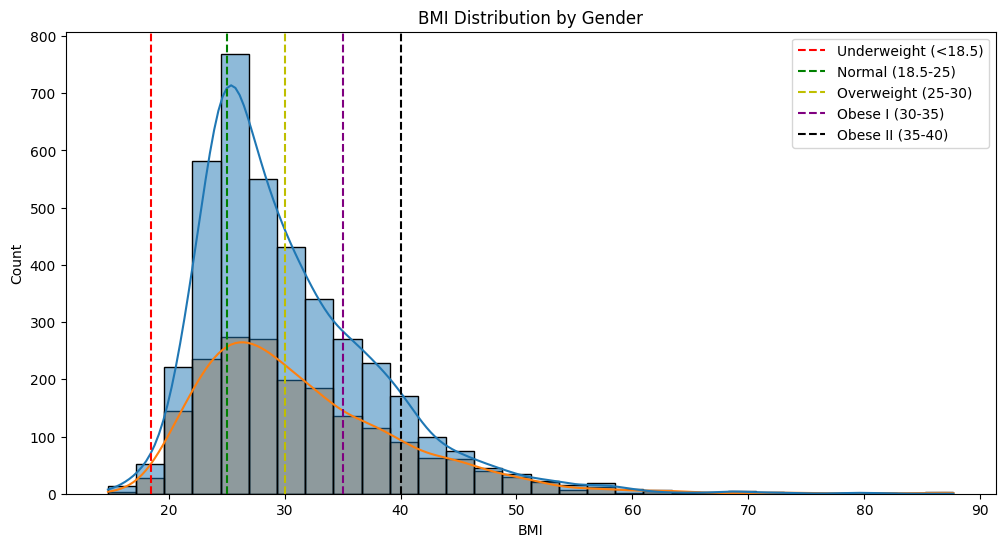


BMI statistics by gender:


,count,mean,std,min,25%,50%,75%,max
is_female,,,,,,,,
False,3967.0,30.363770,7.809086,14.765806,24.963190,28.362732,34.404866,81.211930
True,1932.0,31.643362,9.031923,15.064286,25.170087,29.579491,36.310611,87.675737


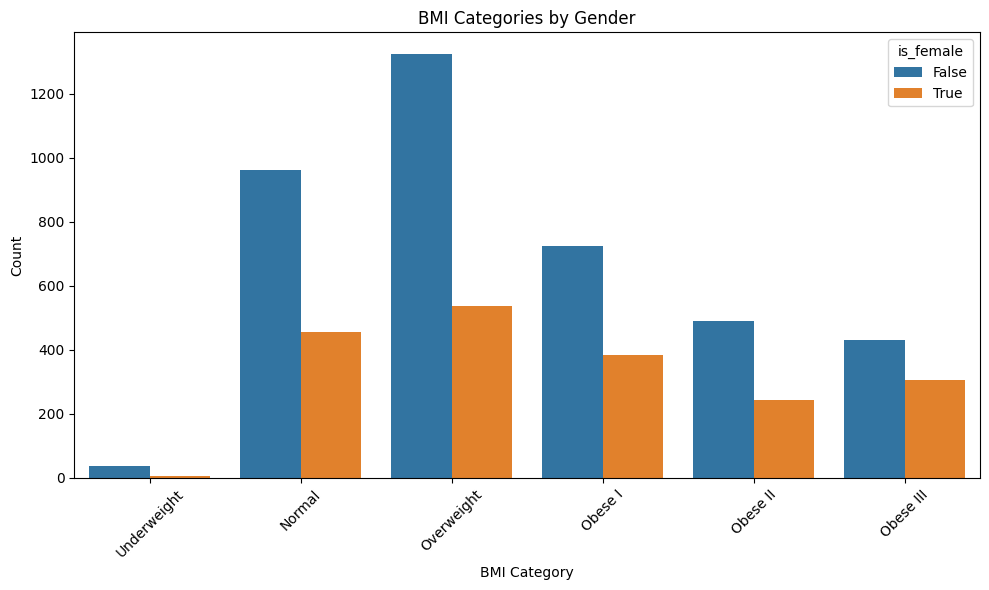

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the parsed Visual BMI dataset
df = pd.read_csv('data/parsed_visual_bmi_dataset.csv')

# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print("\nFirst few rows:")
display(df.head())

print("\nDataset summary statistics:")
display(df.describe())

# Check for missing values
print("\nMissing values in each column:")
display(df.isnull().sum())

# Analyze BMI distribution
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='bmi', hue='is_female', kde=True, bins=30)
plt.title('BMI Distribution by Gender')
plt.xlabel('BMI')
plt.ylabel('Count')
plt.axvline(x=18.5, color='r', linestyle='--', label='Underweight (<18.5)')
plt.axvline(x=25, color='g', linestyle='--', label='Normal (18.5-25)')
plt.axvline(x=30, color='y', linestyle='--', label='Overweight (25-30)')
plt.axvline(x=35, color='purple', linestyle='--', label='Obese I (30-35)')
plt.axvline(x=40, color='black', linestyle='--', label='Obese II (35-40)')
plt.legend()
plt.show()

# BMI statistics by gender
print("\nBMI statistics by gender:")
display(df.groupby('is_female')['bmi'].describe())

# Count individuals in each BMI category
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    elif bmi < 35:
        return 'Obese I'
    elif bmi < 40:
        return 'Obese II'
    else:
        return 'Obese III'

df['bmi_category'] = df['bmi'].apply(bmi_category)

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='bmi_category', hue='is_female', order=['Underweight', 'Normal', 'Overweight', 'Obese I', 'Obese II', 'Obese III'])
plt.title('BMI Categories by Gender')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
